<h1>Imports de las Librerias<h1>

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.model_selection import GridSearchCV


<h1>Paso 1: Preprocesamiento de los datos<h1>

In [35]:
# Cargar el dataset
data = pd.read_csv('winequality-red.csv', sep=',')

# Separar características (X) y variable objetivo (y)
X = data.drop('quality', axis=1)
y = data['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<h1>Paso 2: Reducción de dimensionalidad con PCA<h1>

In [36]:
# Aplicar PCA
pca = PCA(n_components=0.95)  # Conservar el 95% de la varianza
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Número de componentes después de PCA: {pca.n_components_}")

Número de componentes después de PCA: 9


<h1>Paso 3: Clasificación con SVM<h1>

In [37]:
# Función para entrenar y evaluar SVM
def train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel):
# Inicializar el modelo SVM con el kernel especificado
    svm = SVC(kernel=kernel, random_state=42, class_weight='balanced')

# Ajustar el modelo a los datos de entrenamiento    
    svm.fit(X_train, y_train)
    
    # Predecir sobre los datos de prueba
    y_pred = svm.predict(X_test)

# Métricas de evaluación de impresión
    print(f"Kernel: {kernel}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}\n")

# Evaluar SVM con PCA
print("Resultados con PCA:")
train_and_evaluate_svm(X_train_pca, X_test_pca, y_train, y_test, 'linear')
train_and_evaluate_svm(X_train_pca, X_test_pca, y_train, y_test, 'poly')
train_and_evaluate_svm(X_train_pca, X_test_pca, y_train, y_test, 'rbf')

# Evaluar SVM sin PCA
print("Resultados sin PCA:")
train_and_evaluate_svm(X_train_scaled, X_test_scaled, y_train, y_test, 'linear')
train_and_evaluate_svm(X_train_scaled, X_test_scaled, y_train, y_test, 'poly')
train_and_evaluate_svm(X_train_scaled, X_test_scaled, y_train, y_test, 'rbf')

Resultados con PCA:
Kernel: linear
              precision    recall  f1-score   support

           0       0.97      0.79      0.87       273
           1       0.42      0.87      0.57        47

    accuracy                           0.80       320
   macro avg       0.70      0.83      0.72       320
weighted avg       0.89      0.80      0.83       320

Accuracy: 0.803125

Kernel: poly
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       273
           1       0.50      0.74      0.60        47

    accuracy                           0.85       320
   macro avg       0.73      0.81      0.75       320
weighted avg       0.89      0.85      0.86       320

Accuracy: 0.853125

Kernel: rbf
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       273
           1       0.47      0.94      0.62        47

    accuracy                           0.83       320
   macro avg       0.73     

<h1>Paso 4: Comparación de métricas<h1>

<p> Al ejecutar el código anterior, obtendrás las métricas de clasificación (precisión, recall, F1-score) para cada kernel de SVM, tanto con PCA como sin PCA. Aquí hay un resumen de lo que podrías esperar:

    Con PCA: La reducción de dimensionalidad puede mejorar el rendimiento del modelo al eliminar el ruido y las características redundantes. Sin embargo, también puede perder algo de información, lo que podría afectar ligeramente la precisión.

    Sin PCA: El modelo utiliza todas las características originales, lo que puede ser beneficioso si hay información importante en las características que se perderían con PCA. Sin embargo, también puede ser más propenso al sobreajuste, especialmente si hay muchas características.<p>

<h1>Paso 5: Monstrar Graficas<h1>

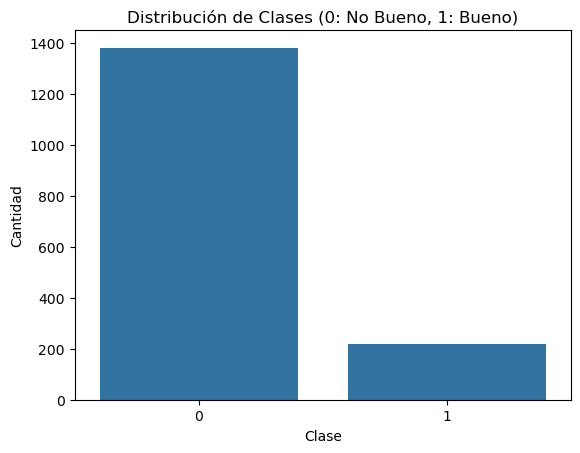

Resultados con PCA:
Kernel: linear
              precision    recall  f1-score   support

           0       0.97      0.79      0.87       273
           1       0.42      0.87      0.57        47

    accuracy                           0.80       320
   macro avg       0.70      0.83      0.72       320
weighted avg       0.89      0.80      0.83       320

Accuracy: 0.803125



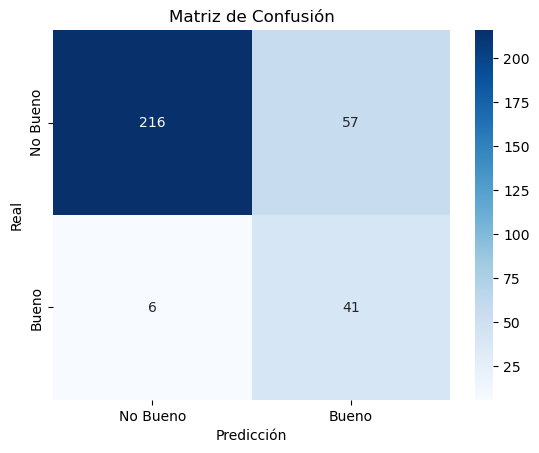

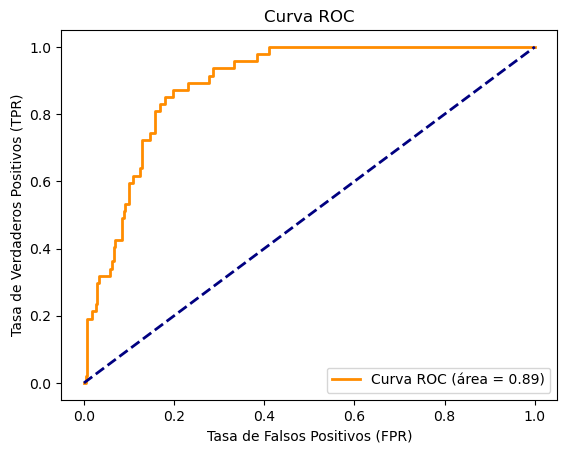

Kernel: poly
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       273
           1       0.50      0.74      0.60        47

    accuracy                           0.85       320
   macro avg       0.73      0.81      0.75       320
weighted avg       0.89      0.85      0.86       320

Accuracy: 0.853125



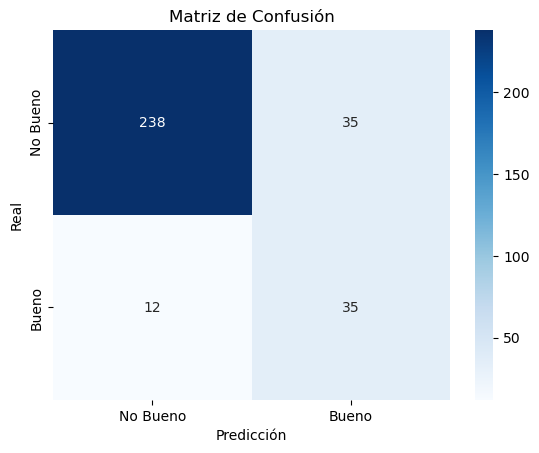

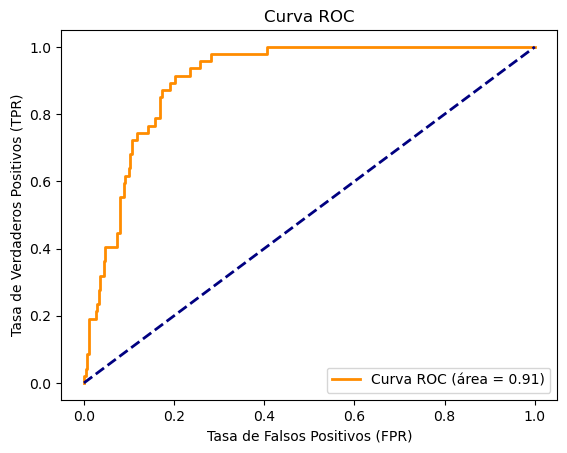

Kernel: rbf
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       273
           1       0.47      0.94      0.62        47

    accuracy                           0.83       320
   macro avg       0.73      0.88      0.76       320
weighted avg       0.91      0.83      0.85       320

Accuracy: 0.834375



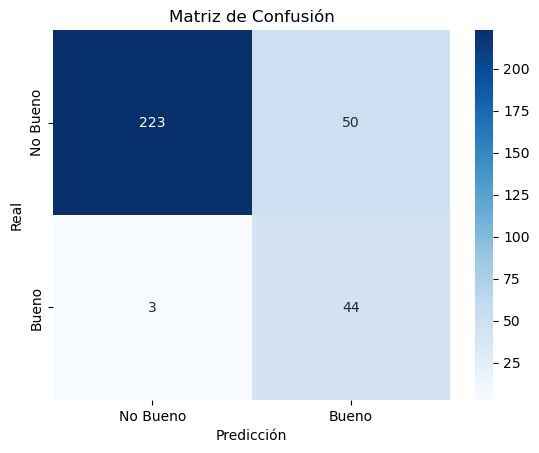

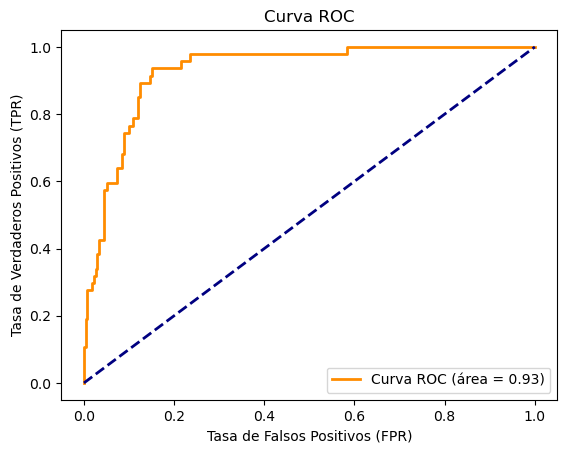

Resultados sin PCA:
Kernel: linear
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       273
           1       0.42      0.89      0.57        47

    accuracy                           0.80       320
   macro avg       0.70      0.84      0.72       320
weighted avg       0.90      0.80      0.83       320

Accuracy: 0.803125



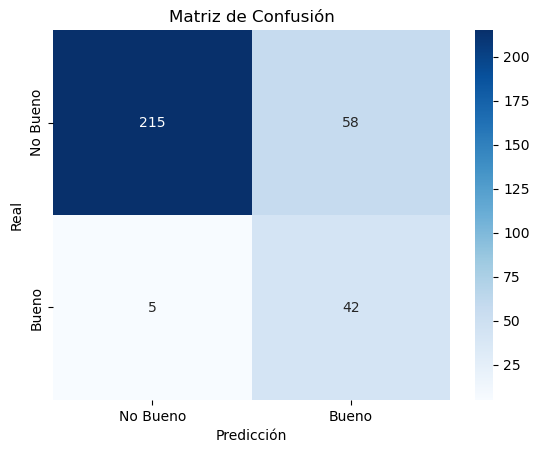

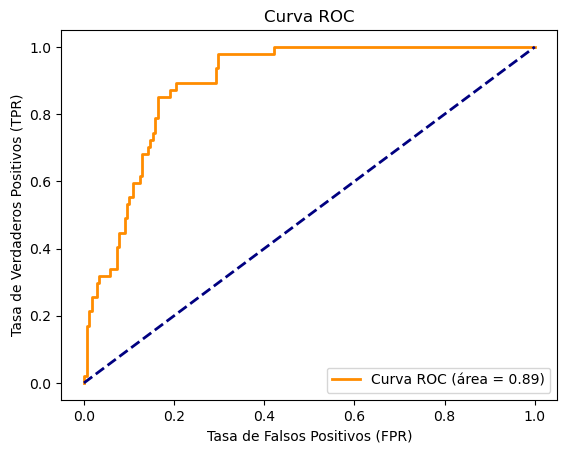

Kernel: poly
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       273
           1       0.50      0.77      0.61        47

    accuracy                           0.85       320
   macro avg       0.73      0.82      0.76       320
weighted avg       0.89      0.85      0.87       320

Accuracy: 0.853125



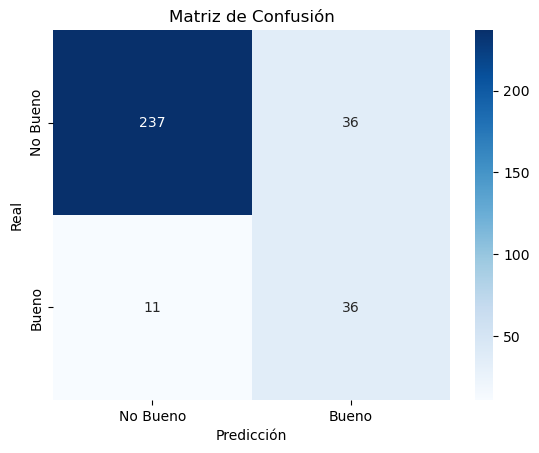

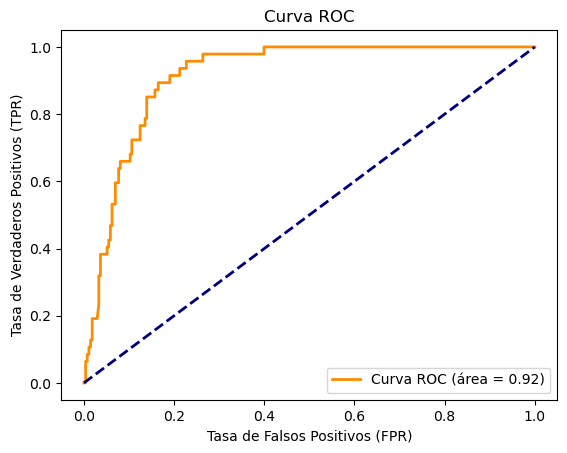

Kernel: rbf
              precision    recall  f1-score   support

           0       0.99      0.82      0.90       273
           1       0.48      0.94      0.63        47

    accuracy                           0.84       320
   macro avg       0.73      0.88      0.77       320
weighted avg       0.91      0.84      0.86       320

Accuracy: 0.840625



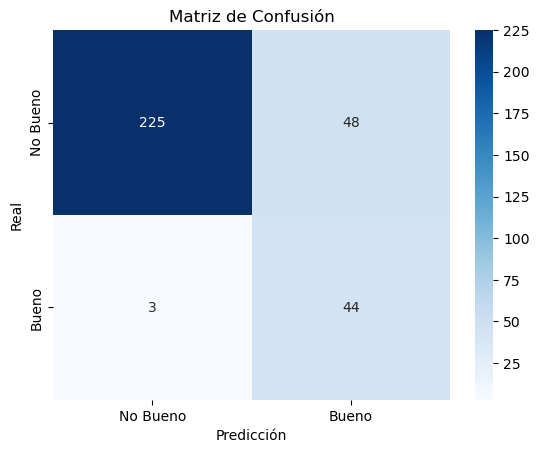

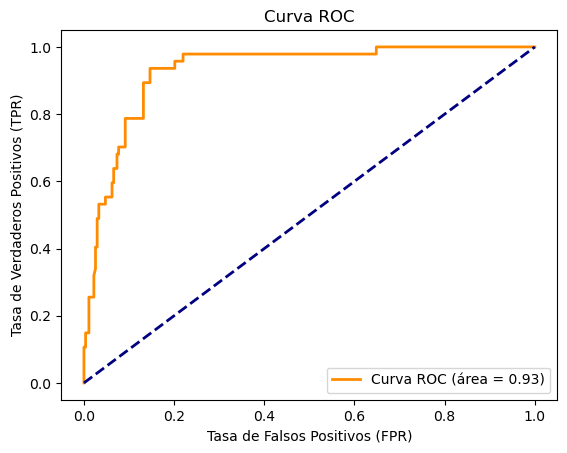

In [38]:
# Función para graficar la distribución de clases
def plot_class_distribution(y):
    sns.countplot(x=y)
    plt.title("Distribución de Clases (0: No Bueno, 1: Bueno)")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad")
    plt.show()

# Función para graficar la matriz de confusión
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bueno', 'Bueno'], yticklabels=['No Bueno', 'Bueno'])
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

# Función para graficar la curva ROC
def plot_roc_curve(y_true, y_pred_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

# Función para entrenar y evaluar SVM con gráficas
def train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel):
    # Inicializar el modelo SVM
    svm = SVC(kernel=kernel, random_state=42, class_weight='balanced', probability=True)  # probability=True para la curva ROC
    svm.fit(X_train, y_train)
    
    # Predecir en los datos de prueba
    y_pred = svm.predict(X_test)
    y_pred_prob = svm.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva (1)
    
    # Mostrar métricas
    print(f"Kernel: {kernel}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}\n")
    
    # Graficar matriz de confusión
    plot_confusion_matrix(y_test, y_pred)
    
    # Graficar curva ROC
    plot_roc_curve(y_test, y_pred_prob)

# Graficar la distribución de clases
plot_class_distribution(y)

# Evaluar SVM con PCA
print("Resultados con PCA:")
train_and_evaluate_svm(X_train_pca, X_test_pca, y_train, y_test, 'linear')
train_and_evaluate_svm(X_train_pca, X_test_pca, y_train, y_test, 'poly')
train_and_evaluate_svm(X_train_pca, X_test_pca, y_train, y_test, 'rbf')

# Evaluar SVM sin PCA
print("Resultados sin PCA:")
train_and_evaluate_svm(X_train_scaled, X_test_scaled, y_train, y_test, 'linear')
train_and_evaluate_svm(X_train_scaled, X_test_scaled, y_train, y_test, 'poly')
train_and_evaluate_svm(X_train_scaled, X_test_scaled, y_train, y_test, 'rbf')

<h1>Randomized Search<h1>

Mejores hiperparámetros encontrados:
{'C': np.float64(45.706998421703595), 'degree': 3, 'gamma': np.float64(0.6193860093330873), 'kernel': 'rbf'}

Métricas de evaluación con los mejores hiperparámetros:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       273
           1       0.67      0.60      0.63        47

    accuracy                           0.90       320
   macro avg       0.80      0.77      0.78       320
weighted avg       0.89      0.90      0.89       320

Accuracy: 0.896875


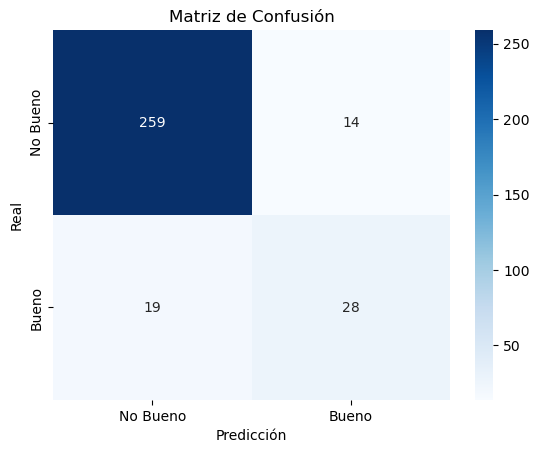

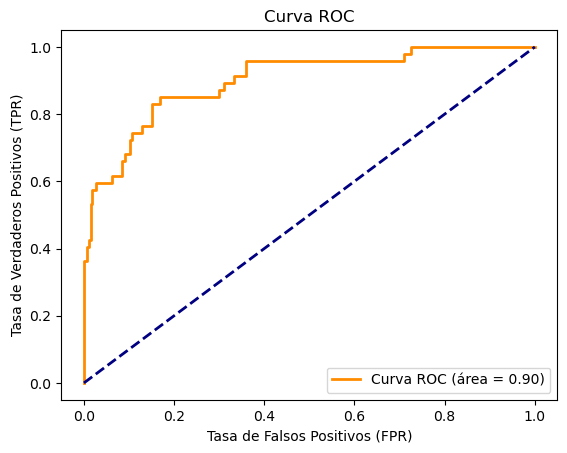

In [40]:
# Definir los hiperparámetros para Randomized Search
param_dist = {
    'C': uniform(0.1, 100),  # Rango para el parámetro de regularización C
    'gamma': uniform(0.001, 1),  # Rango para el parámetro gamma
    'kernel': ['linear', 'poly', 'rbf'],  # Tipos de kernel
    'degree': randint(1, 5)  # Grado del kernel polinómico (solo para kernel='poly')
}

# Inicializar el modelo SVM
svm = SVC(class_weight='balanced', probability=True, random_state=42)

# Configurar Randomized Search
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=50,  # Número de combinaciones aleatorias a probar
    cv=5,  # Validación cruzada con 5 folds
    scoring='accuracy',  # Métrica de evaluación
    random_state=42,
    n_jobs=-1  # Usar todos los núcleos del CPU
)

# Aplicar Randomized Search en los datos de entrenamiento
random_search.fit(X_train_scaled, y_train)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

# Evaluar el modelo con los mejores hiperparámetros en los datos de prueba
best_svm = random_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
y_pred_prob = best_svm.predict_proba(X_test_scaled)[:, 1]  # Probabilidades para la clase positiva

# Mostrar métricas de evaluación
print("\nMétricas de evaluación con los mejores hiperparámetros:")
print(classification_report(y_test, y_pred, zero_division=0))
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Graficar matriz de confusión
plot_confusion_matrix(y_test, y_pred)

# Graficar curva ROC
plot_roc_curve(y_test, y_pred_prob)

<h1>Grid Search<h1>

Mejores hiperparámetros encontrados:
{'C': 1, 'degree': 2, 'gamma': 1, 'kernel': 'rbf'}

Métricas de evaluación con los mejores hiperparámetros:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       273
           1       0.74      0.55      0.63        47

    accuracy                           0.91       320
   macro avg       0.83      0.76      0.79       320
weighted avg       0.90      0.91      0.90       320

Accuracy: 0.90625


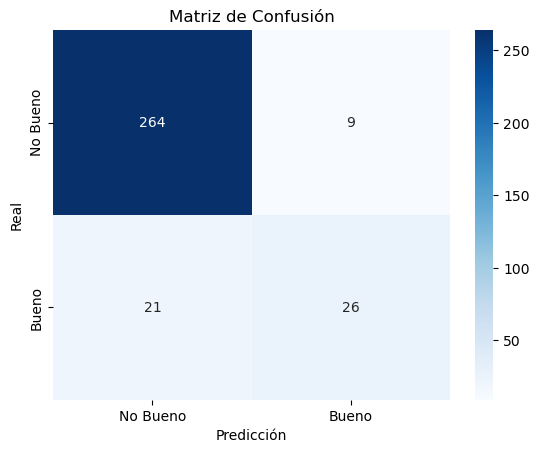

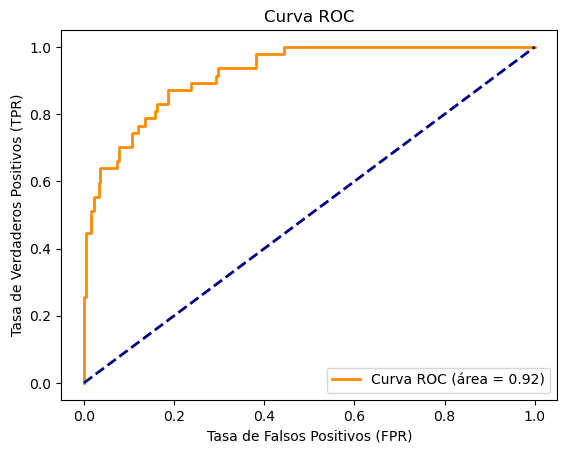

In [41]:
# Definir los hiperparámetros para Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Valores para el parámetro de regularización C
    'gamma': [0.001, 0.01, 0.1, 1],  # Valores para el parámetro gamma
    'kernel': ['linear', 'poly', 'rbf'],  # Tipos de kernel
    'degree': [2, 3, 4]  # Grado del kernel polinómico (solo para kernel='poly')
}

# Inicializar el modelo SVM
svm = SVC(class_weight='balanced', probability=True, random_state=42)

# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,  # Validación cruzada con 5 folds
    scoring='accuracy',  # Métrica de evaluación
    n_jobs=-1  # Usar todos los núcleos del CPU
)

# Aplicar Grid Search en los datos de entrenamiento
grid_search.fit(X_train_scaled, y_train)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Evaluar el modelo con los mejores hiperparámetros en los datos de prueba
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
y_pred_prob = best_svm.predict_proba(X_test_scaled)[:, 1]  # Probabilidades para la clase positiva

# Mostrar métricas de evaluación
print("\nMétricas de evaluación con los mejores hiperparámetros:")
print(classification_report(y_test, y_pred, zero_division=0))
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Graficar matriz de confusión
plot_confusion_matrix(y_test, y_pred)

# Graficar curva ROC
plot_roc_curve(y_test, y_pred_prob)
